In [1]:
import sys
!{sys.executable} -m pip install shap

   ---------------------------------------- 0.0/555.9 kB ? eta -:--:--
   ---------------------------------------- 555.9/555.9 kB 7.0 MB/s  0:00:00

   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   ---------------------------------------- 2/2 [shap]



# SHAP Explainability Analysis

This notebook uses SHAP (Shapley Additive Explanations) to explain the Logistic Regression model's predictions at both global and local levels. Global explainability reveals which features drive the model's decisions across all patients, while local explainability explains individual patient predictions. This directly addresses the project's research question: "Which clinical features strongly influence disease
risk predictions?"

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap
import pickle

file_path = r"C:\Courses\DAMG6105\Project - Disease Prediction System"

# Load processed splits
X_train = pd.read_csv(f'{file_path}/data/processed/X_train.csv')
X_test = pd.read_csv(f'{file_path}/data/processed/X_test.csv')
y_test = pd.read_csv(f'{file_path}/data/processed/y_test.csv').squeeze()
y_test = y_test.apply(lambda x: 1 if x > 0 else 0)

# Load saved Logistic Regression model
with open(f'{file_path}/outputs/models/logistic_regression.pkl', 'rb') as f:
    lr_model = pickle.load(f)

print("Data and model loaded successfully.")
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

Data and model loaded successfully.
X_train shape: (644, 15)
X_test shape: (138, 15)


In [4]:
# Create SHAP explainer
explainer = shap.LinearExplainer(lr_model, X_train)

# Calculate SHAP values for test set
shap_values = explainer.shap_values(X_test)

print("SHAP explainer created successfully.")
print("SHAP values shape:", shap_values.shape)
print("Each row = one patient, each column = one feature")

SHAP explainer created successfully.
SHAP values shape: (138, 15)
Each row = one patient, each column = one feature


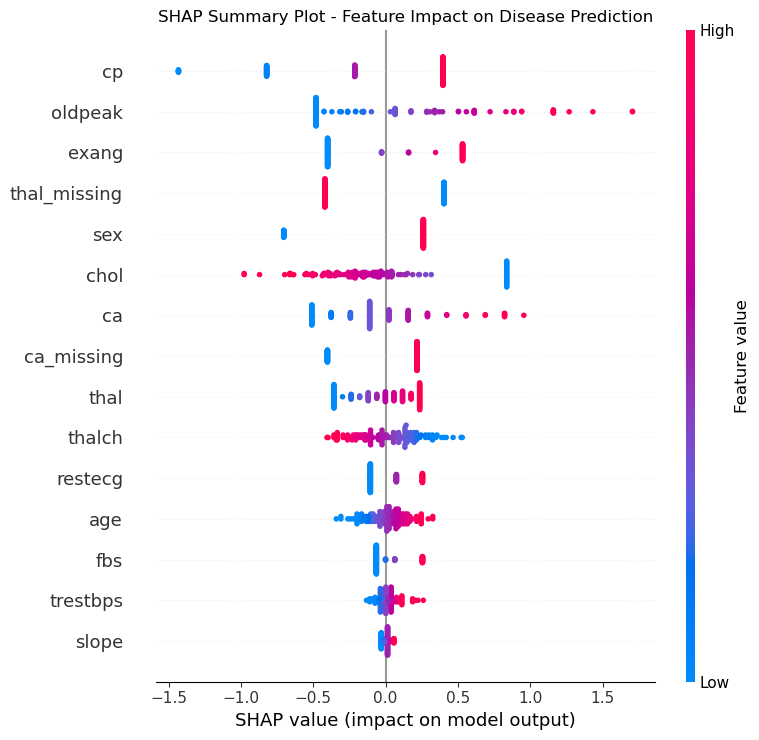

In [5]:
# SHAP Summary Plot
plt.figure()
shap.summary_plot(shap_values, X_test, 
                  feature_names=X_test.columns.tolist(),
                  show=False)

plt.title('SHAP Summary Plot - Feature Impact on Disease Prediction')
plt.tight_layout()
plt.savefig(f'{file_path}/outputs/figures/shap_summary_plot.png',
            bbox_inches='tight')
plt.show()

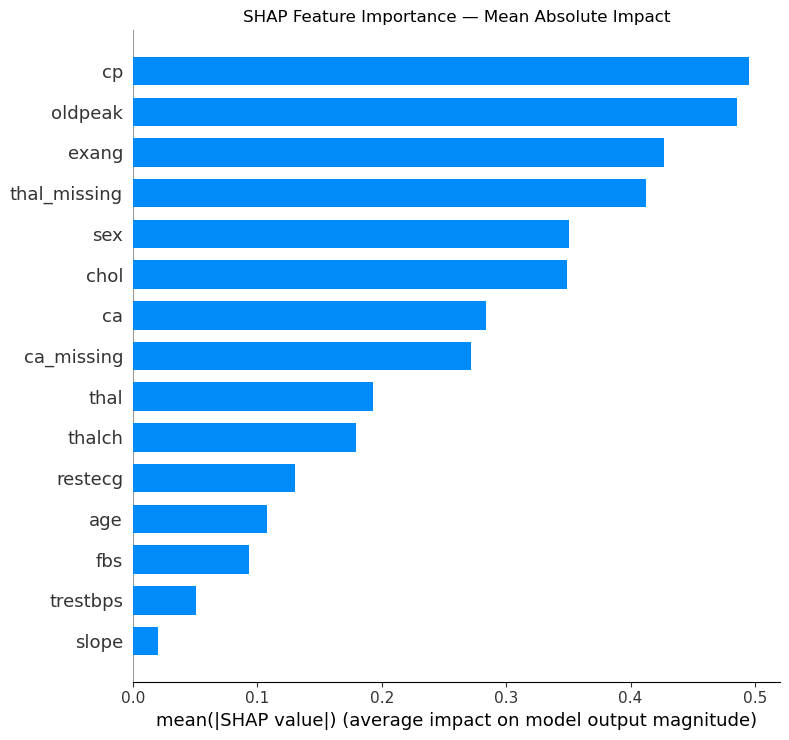

In [6]:
# SHAP Bar Plot - Mean Absolute Feature Importance
plt.figure()
shap.summary_plot(shap_values, X_test,
                  feature_names=X_test.columns.tolist(),
                  plot_type='bar',
                  show=False)
plt.title('SHAP Feature Importance - Mean Absolute Impact')
plt.tight_layout()
plt.savefig(f'{file_path}/outputs/figures/shap_bar_plot.png',
            bbox_inches='tight')
plt.show()

In [8]:
from sklearn.linear_model import LogisticRegression

# Recreate optimal predictions using threshold 0.45
y_prob_test = lr_model.predict_proba(X_test)[:, 1]
y_pred_optimal = (y_prob_test >= 0.45).astype(int)

print("Optimal predictions recreated.")
print("Missed diagnoses:", sum((y_test.values == 1) & (y_pred_optimal == 0)))
print("False alarms:", sum((y_test.values == 0) & (y_pred_optimal == 1)))

Optimal predictions recreated.
Missed diagnoses: 5
False alarms: 13


Correctly predicted disease patient index: 0
Missed diagnosis patient index: 60


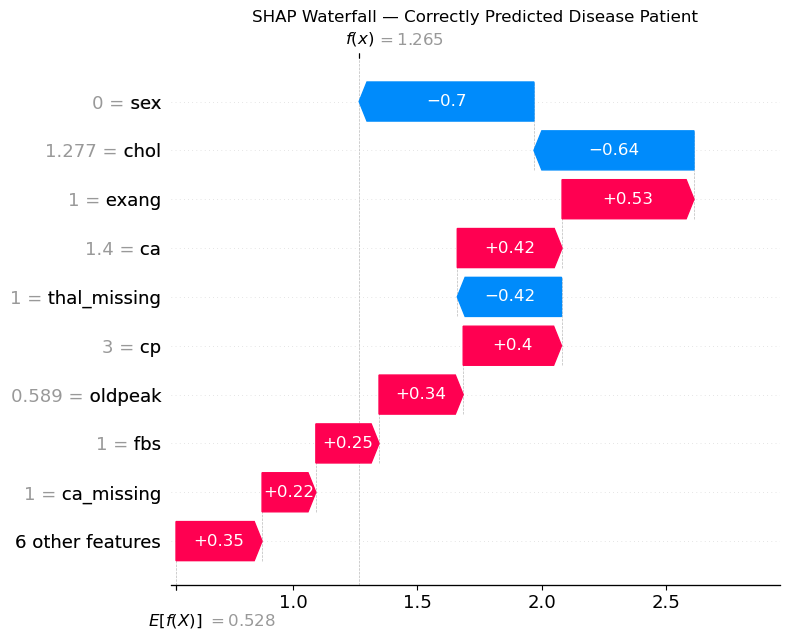

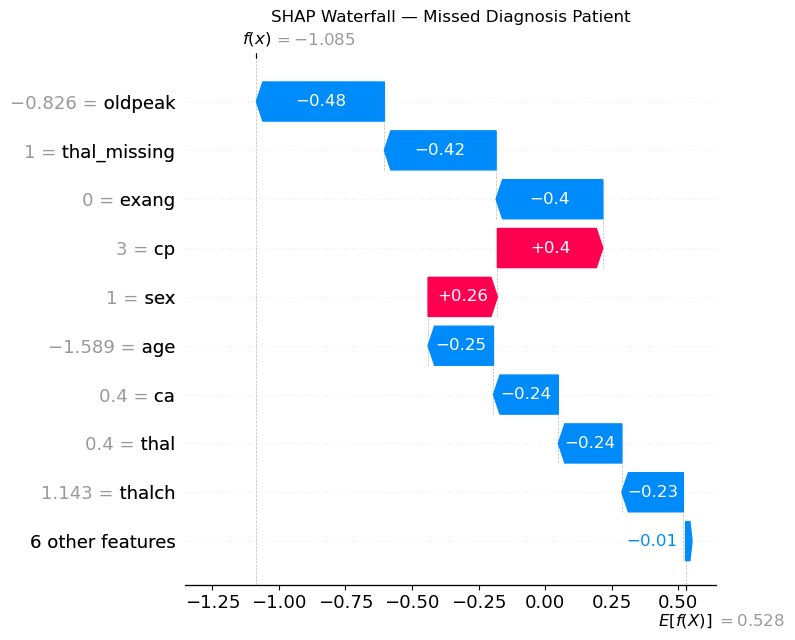

In [10]:
# Find a correctly predicted disease patient
correct_disease_idx = np.where(
    (y_test.values == 1) & (y_pred_optimal == 1)
)[0][0]

# Find a missed diagnosis patient
missed_idx = np.where(
    (y_test.values == 1) & (y_pred_optimal == 0)
)[0][0]

print(f"Correctly predicted disease patient index: {correct_disease_idx}")
print(f"Missed diagnosis patient index: {missed_idx}")

# Waterfall plot for correctly predicted disease patient
plt.figure()
shap.waterfall_plot(
    shap.Explanation(
        values=shap_values[correct_disease_idx],
        base_values=explainer.expected_value,
        data=X_test.iloc[correct_disease_idx],
        feature_names=X_test.columns.tolist()
    ),
    show=False
)

plt.title('SHAP Waterfall — Correctly Predicted Disease Patient')
plt.tight_layout()
plt.savefig(f'{file_path}/outputs/figures/shap_waterfall_correct.png',
            bbox_inches='tight')
plt.show()

# Waterfall plot for missed diagnosis patient
plt.figure()
shap.waterfall_plot(
    shap.Explanation(
        values=shap_values[missed_idx],
        base_values=explainer.expected_value,
        data=X_test.iloc[missed_idx],
        feature_names=X_test.columns.tolist()
    ),
    show=False
)
plt.title('SHAP Waterfall - Missed Diagnosis Patient')
plt.tight_layout()
plt.savefig(f'{file_path}/outputs/figures/shap_waterfall_missed.png',
            bbox_inches='tight')
plt.show()

## SHAP Waterfall Analysis

### Correctly Predicted Disease Patient (Index 0)
- Starting from baseline prediction of 0.528, final prediction reached 1.265
- Strongest pushes toward disease:
  - exang=1 (+0.53) - exercise induced angina present
  - ca=1.4 (+0.42) - major vessels blocked
  - cp=3 (+0.40) - asymptomatic chest pain
- Notable pushes away from disease:
  - sex=0 (-0.70) - female patient, consistent with lower female disease rates in training data
  - chol=1.277 (-0.64) - consistent with cholesterol's counterintuitive negative relationship identified in EDA
- Despite female sex reducing predicted risk, overwhelming disease indicators resulted in correct classification

### Missed Diagnosis Patient (Index 60)
- Starting from baseline of 0.528, final prediction reached -1.085 - well below decision threshold
- Almost every feature pushed away from disease:
  - oldpeak=-0.826 (-0.48) - very low ST depression
  - thal_missing=1 (-0.42) - missing thal value reduced risk score
  - exang=0 (-0.40) - no exercise induced angina
  - age=-1.589 (-0.25) - young patient, well below average age
  - ca=0.4 (-0.24) - low vessel blockage
- Only cp=3 (+0.40) pushed toward disease - insufficient to overcome all negative signals
- This patient presented so atypically that virtually no disease indicators fired, a genuinely difficult case that highlights the
  inherent limitations of pattern based prediction systems

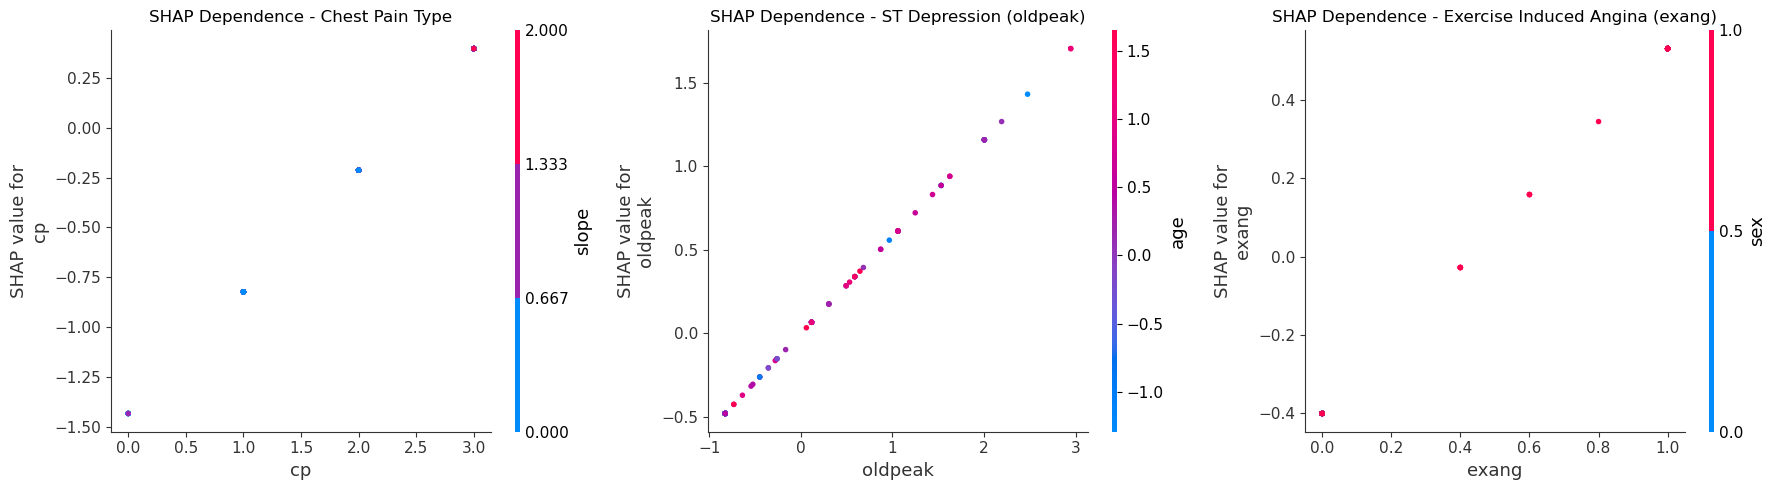

In [12]:
# SHAP Dependence Plots for top 3 features

top_features = ['cp', 'oldpeak', 'exang']
titles = ['Chest Pain Type', 'ST Depression (oldpeak)', 
          'Exercise Induced Angina (exang)']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, (feature, title) in enumerate(zip(top_features, titles)):
    shap.dependence_plot(
        feature,
        shap_values,
        X_test,
        ax=axes[i],
        show=False
    )
    axes[i].set_title(f'SHAP Dependence - {title}')

plt.tight_layout()
plt.savefig(f'{file_path}/outputs/figures/shap_dependence_plots.png',
            bbox_inches='tight')
plt.show()

## SHAP Dependence Plot Analysis

### Chest Pain Type (cp)
- SHAP values increase as cp goes from 0 to 3 - directly proportional
- Asymptomatic patients (cp=3) receive the highest disease risk push, consistent with EDA finding of 77% disease rate in asymptomatic patients
- Counterintuitively, no chest pain symptoms = highest disease risk

### ST Depression (oldpeak)
- SHAP values increase with higher oldpeak values - directly proportional
- Higher ST depression during exercise indicates greater cardiac stress, clinically consistent with coronary artery disease progression

### Exercise Induced Angina (exang)
- Binary feature showing clear separation - exang=1 produces significantly higher SHAP values than exang=0
- Presence of exercise induced angina is one of the strongest individual disease indicators in the dataset, consistent with both EDA correlation
  (0.433) and feature coefficient (0.932) findings

### Overall Finding
- All three top features show direct positive relationships with disease risk, higher values consistently indicate higher disease probability
- This consistency across SHAP dependence plots, EDA correlations, and feature coefficients provides strong validation of the model's learned
  patterns and their clinical interpretability

# Notebook 07 Summary - SHAP Explainability

## Overview
SHAP (SHapley Additive exPlanations) was applied to the final Logistic Regression model to explain predictions at both global and local levels.
SHAP values were calculated for all 138 test patients, producing a complete explainability analysis across four visualization types.

## Global Explainability - Feature Importance

### Top Features by Mean Absolute SHAP Value
| Rank | Feature | Clinical Meaning |
|---|---|---|
| 1 | cp | Chest pain type - asymptomatic highest risk |
| 2 | oldpeak | ST depression during exercise |
| 3 | exang | Exercise induced angina |
| 4 | thal_missing | Missingness of thal value |
| 5 | sex | Male sex associated with higher risk |
| 6 | chol | Counterintuitive negative relationship |

### Validation Across Three Methods
| Feature | EDA Correlation | Coefficient | SHAP Rank |
|---|---|---|---|
| cp | 0.426 | +0.609 | 1st |
| oldpeak | 0.345 | +0.580 | 2nd |
| exang | 0.433 | +0.932 | 3rd |
| sex | 0.306 | +0.965 | 5th |
| thalch | -0.381 | -0.199 | 10th |

Three independent methods - EDA correlation, feature coefficients, and SHAP, consistently identify the same features as most influential,
strongly validating the model's learned patterns.

## Local Explainability - Individual Patients

### Correctly Predicted Disease Patient
- Starting baseline: 0.528, Final prediction: 1.265
- Driven by exang (+0.53), ca (+0.42), cp (+0.40)
- Female sex (-0.70) and cholesterol (-0.64) reduced risk score
- Overwhelming disease indicators resulted in correct classification despite mitigating features

### Missed Diagnosis Patient
- Starting baseline: 0.528, Final prediction: -1.085
- Nearly every feature pushed away from disease
- Young age, low oldpeak, no exercise angina, missing thal value
- Only cp=3 pushed toward disease - insufficient to overcome all negative signals
- Highlights inherent limitation of pattern based prediction for atypical disease presentations

## Dependence Plot Findings
- All three top features (cp, oldpeak, exang) show direct positive relationships with disease risk - higher values = higher disease
  probability
- Clinically consistent with established cardiovascular risk factors

## Key Contribution to Research Questions
This analysis directly answers the project research question:
"Which clinical features strongly influence disease risk predictions?"

Answer: Chest pain type, ST depression, and exercise induced angina are the three strongest clinical predictors. These are consistent across EDA,
modeling, and explainability analysis. This finding is clinically interpretable and aligns with established cardiovascular medicine.